# Piloto 2026 · aromas con transferencia gas–líquido

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "fermentation_model").exists():
    ROOT = ROOT.parent
if not (ROOT / "fermentation_model").exists():
    raise RuntimeError("Execute from the repository or a descendant directory")
import os
sys.path.insert(0, str(ROOT / "fermentation_model"))
from pilot_2026 import run_aroma_co2_release_recalibration_2026 as analysis
result = analysis.load_results() if os.environ.get("PILOT_AROMA_REUSE_RESULTS") == "1" else analysis.run_analysis()
print("Resultados:", analysis.RESULTS_DIR.relative_to(ROOT))

Resultados: fermentation_model\pilot_2026\results\aroma_dynamic_transfer_recalibration_2026


## tl;dr

In [2]:
summary = result["summary"]
display(summary["holdout_rmse_comparison"])
print("Mediana de recambios gaseosos acumulados:", round(summary["median_integrated_gas_turnover"], 4))
print("Pérdida identificada:", summary["loss_identified_with_dynamic_transfer"])
print("26157 MIX-03:", summary["ethyl_octanoate_26157_mix03"])
print("Gate:", result["gate"]["verdict"])

{'condensate__ethyl_acetate': {'dynamic_transfer_rmse': nan,
  'empirical_mass_basis_rmse': nan,
  'relative_change': nan},
 'condensate__ethyl_octanoate': {'dynamic_transfer_rmse': 846.341337324888,
  'empirical_mass_basis_rmse': 846.1259014468591,
  'relative_change': 0.00025461444645587505},
 'condensate__isoamyl_acetate': {'dynamic_transfer_rmse': 3072.3317169672905,
  'empirical_mass_basis_rmse': 3078.0869233679455,
  'relative_change': -0.0018697348528279392},
 'wine__ethyl_acetate': {'dynamic_transfer_rmse': 5550.241726617205,
  'empirical_mass_basis_rmse': 5547.758704947049,
  'relative_change': 0.0004475720380451228},
 'wine__ethyl_octanoate': {'dynamic_transfer_rmse': 48.39756257871254,
  'empirical_mass_basis_rmse': 48.41606459819133,
  'relative_change': -0.0003821462903345192},
 'wine__isoamyl_acetate': {'dynamic_transfer_rmse': 724.2754808790875,
  'empirical_mass_basis_rmse': 722.5192413946379,
  'relative_change': 0.0024307165592705824}}

Mediana de recambios gaseosos acumulados: 34.5749
Pérdida identificada: {'ethyl_acetate': True, 'ethyl_octanoate': True, 'isoamyl_acetate': True}
26157 MIX-03: {'released_co2_model': 7.904288958590115, 'dynamic_transfer_model': 5.053205117794947, 'observed_captured_ug': 614.557866106016}
Gate: PASS_CONDITIONAL


## Contexto y métodos

- Se conservan formación aromática, partición UNIFAC, captura, errores y censura.
- Ambos comparadores usan el mismo rCO₂ emitido predicho por `solubility_o2_nitrogen_boost_continuous_release`.
- La corrección convierte masa de CO₂ a `Qgas/VL` con gas ideal y usa `1-exp(-kLa(E)/(Qgas/VL))`.
- `kLa(E)=kLa_ref*mE**((E-50)/10)` permite contrastar directamente el efecto adicional del etanol.
- `K(T, etanol, azúcar)` sigue aportando la dependencia termodinámica con la composición.
- `26158` y `26211` son holdouts tanto para CO₂ como para aromas.
- La primera muestra de vino inicializa la trayectoria y no entra al RMSE de validación; las muestras siguientes sí.
- Se estiman `mass_transfer_kla_ref_h_inv` y el multiplicador de etanol, con eficiencia NTU acotada entre cero y uno.

## Datos y forcing rCO₂

,experiment_id,matrix,role,integrated_rco2_g_l,peak_rco2_g_l_h,integrated_gas_turnover,peak_gas_turnover_h_inv
0,26157,pilot_lot2,calibration,66.8270,0.7554,36.3799,0.4112
1,26158,pilot_lot2,holdout,64.3016,0.7475,35.0043,0.4061
2,26159,pilot_lot2,calibration,64.1903,0.6822,34.6592,0.3674
3,26210,pilot_lot3,calibration,62.7746,0.9241,34.2363,0.5026
4,26211,pilot_lot3,holdout,63.2467,0.9410,34.4906,0.5116
5,26212,pilot_lot3,calibration,61.9066,1.0544,33.7787,0.5787


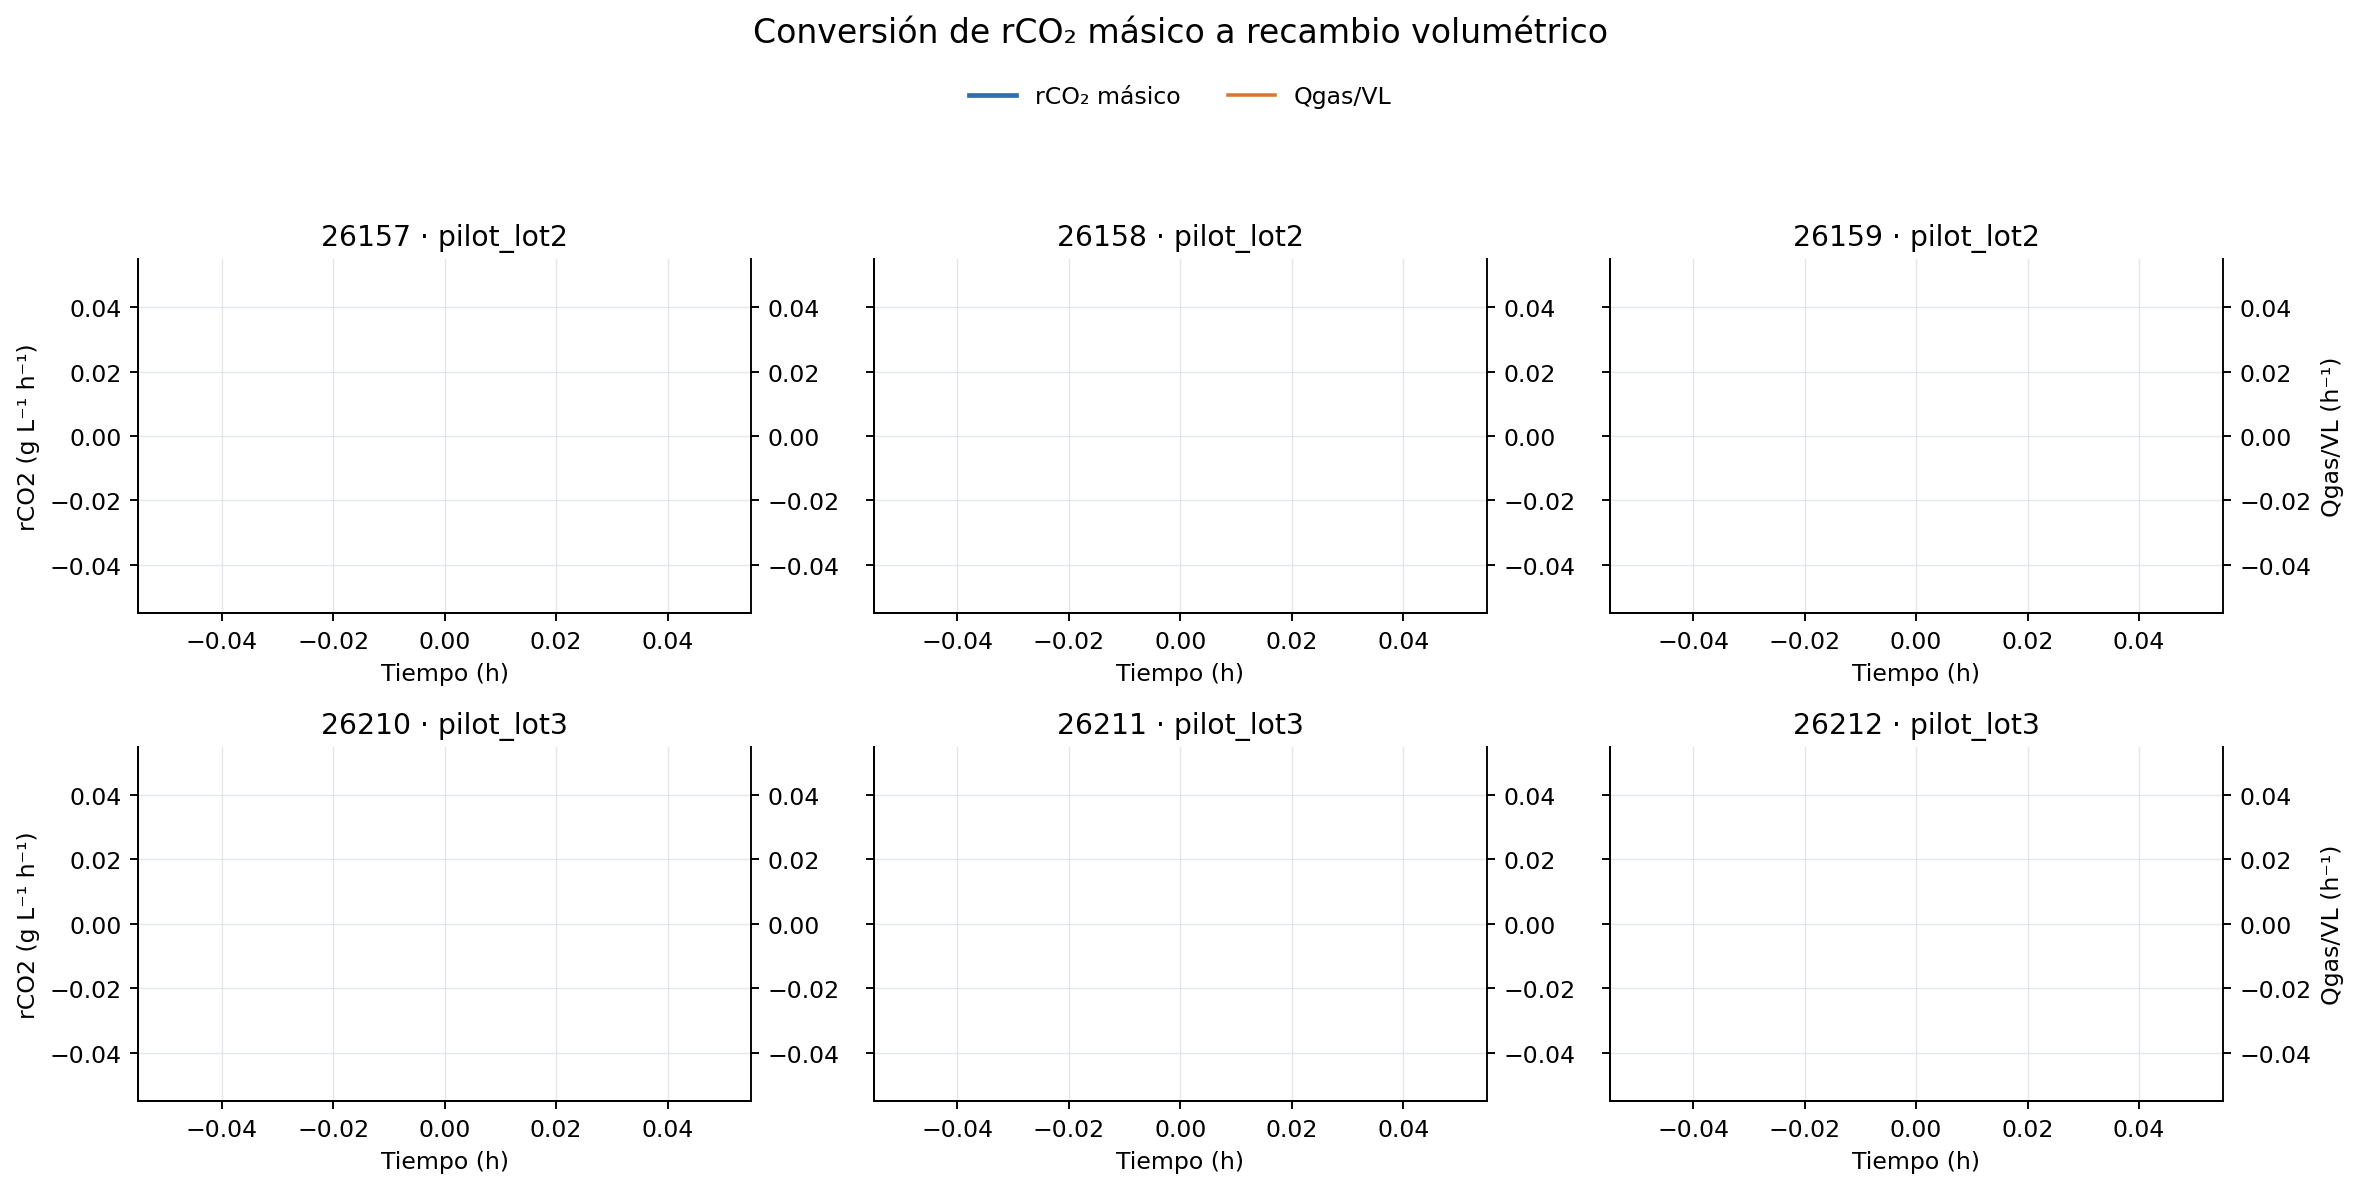

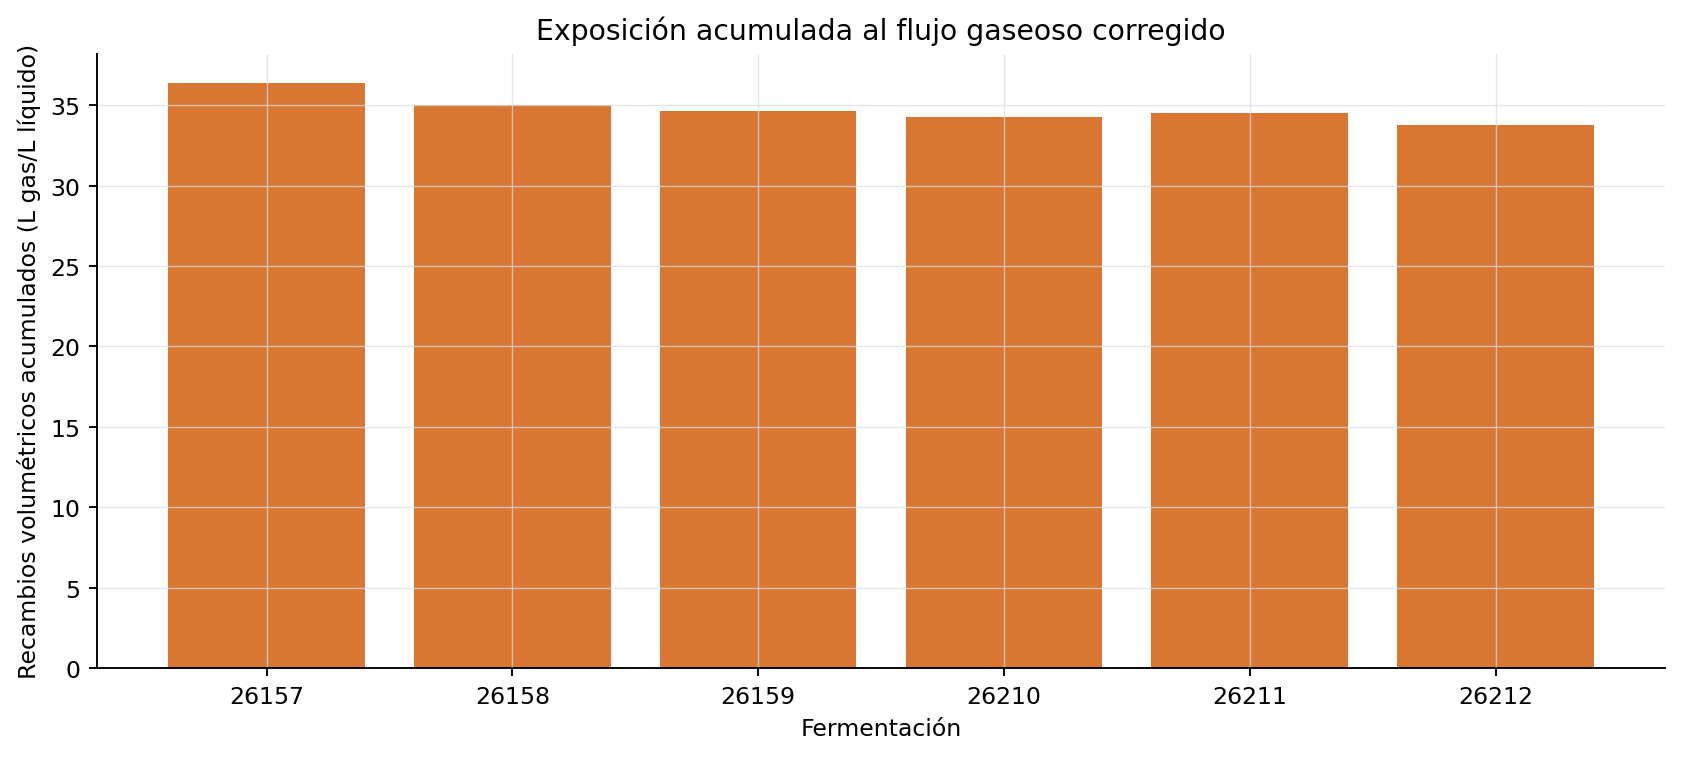

In [3]:
display(result["exposure"].round(4))
display(Image(filename=analysis.FIGURE_DIR / "gas_flow_conversion.png"))
display(Image(filename=analysis.FIGURE_DIR / "integrated_rco2_exposure.png"))

## Resultados de calibración y validación

,forcing_source,fit_scope,species,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
9,released_co2_model,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,42.29298,0.00010,10000.0,False,0.59008
10,released_co2_model,all_data,ethyl_acetate,formation_stationary_ug_per_g_sugar,72.61824,0.00010,10000.0,False,0.08750
11,released_co2_model,all_data,ethyl_acetate,effective_loss_scale,0.00902,0.00001,10.0,False,0.12609
12,released_co2_model,all_data,ethyl_octanoate,formation_growth_ug_per_g_sugar,0.17893,0.00010,10000.0,False,2.16422
13,released_co2_model,all_data,ethyl_octanoate,formation_stationary_ug_per_g_sugar,0.54573,0.00010,10000.0,False,0.18648
14,released_co2_model,all_data,ethyl_octanoate,effective_loss_scale,0.00919,0.00001,10.0,False,0.12598
15,released_co2_model,all_data,isoamyl_acetate,formation_growth_ug_per_g_sugar,0.39824,0.00010,10000.0,False,4.68538
16,released_co2_model,all_data,isoamyl_acetate,formation_stationary_ug_per_g_sugar,7.09023,0.00010,10000.0,False,0.11402
17,released_co2_model,all_data,isoamyl_acetate,effective_loss_scale,0.00715,0.00001,10.0,False,0.07339
30,dynamic_transfer_model,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,41.77011,0.00010,10000.0,False,0.60915


,forcing_source,fit_scope,species,role,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias,n_censored,censor_compliance_fraction
7,dynamic_transfer_model,calibration_only,ethyl_acetate,holdout,wine,11,11378.9113,5550.2417,0.4878,3274.6388,-2607.0950,0,NaN
9,dynamic_transfer_model,calibration_only,ethyl_octanoate,holdout,wine,11,79.7833,48.3976,0.6066,26.8693,-20.9219,0,NaN
11,dynamic_transfer_model,calibration_only,isoamyl_acetate,holdout,wine,11,1099.0934,724.2755,0.6590,499.9171,-425.0511,2,1.0000
19,released_co2_model,calibration_only,ethyl_acetate,holdout,wine,11,11378.9113,5547.7587,0.4875,3272.2318,-2601.1775,0,NaN
21,released_co2_model,calibration_only,ethyl_octanoate,holdout,wine,11,79.7833,48.4161,0.6068,26.8684,-20.9582,0,NaN
23,released_co2_model,calibration_only,isoamyl_acetate,holdout,wine,11,1099.0934,722.5192,0.6574,499.1085,-422.3848,2,1.0000
31,dynamic_transfer_model,calibration_only,ethyl_acetate,holdout,condensate,0,NaN,NaN,NaN,NaN,NaN,11,1.0000
33,dynamic_transfer_model,calibration_only,ethyl_octanoate,holdout,condensate,8,522.5388,846.3413,1.6197,517.7738,-517.7738,3,0.6667
35,dynamic_transfer_model,calibration_only,isoamyl_acetate,holdout,condensate,6,2364.4711,3072.3317,1.2994,2319.3884,-2319.3884,5,1.0000
43,released_co2_model,calibration_only,ethyl_acetate,holdout,condensate,0,NaN,NaN,NaN,NaN,NaN,11,1.0000


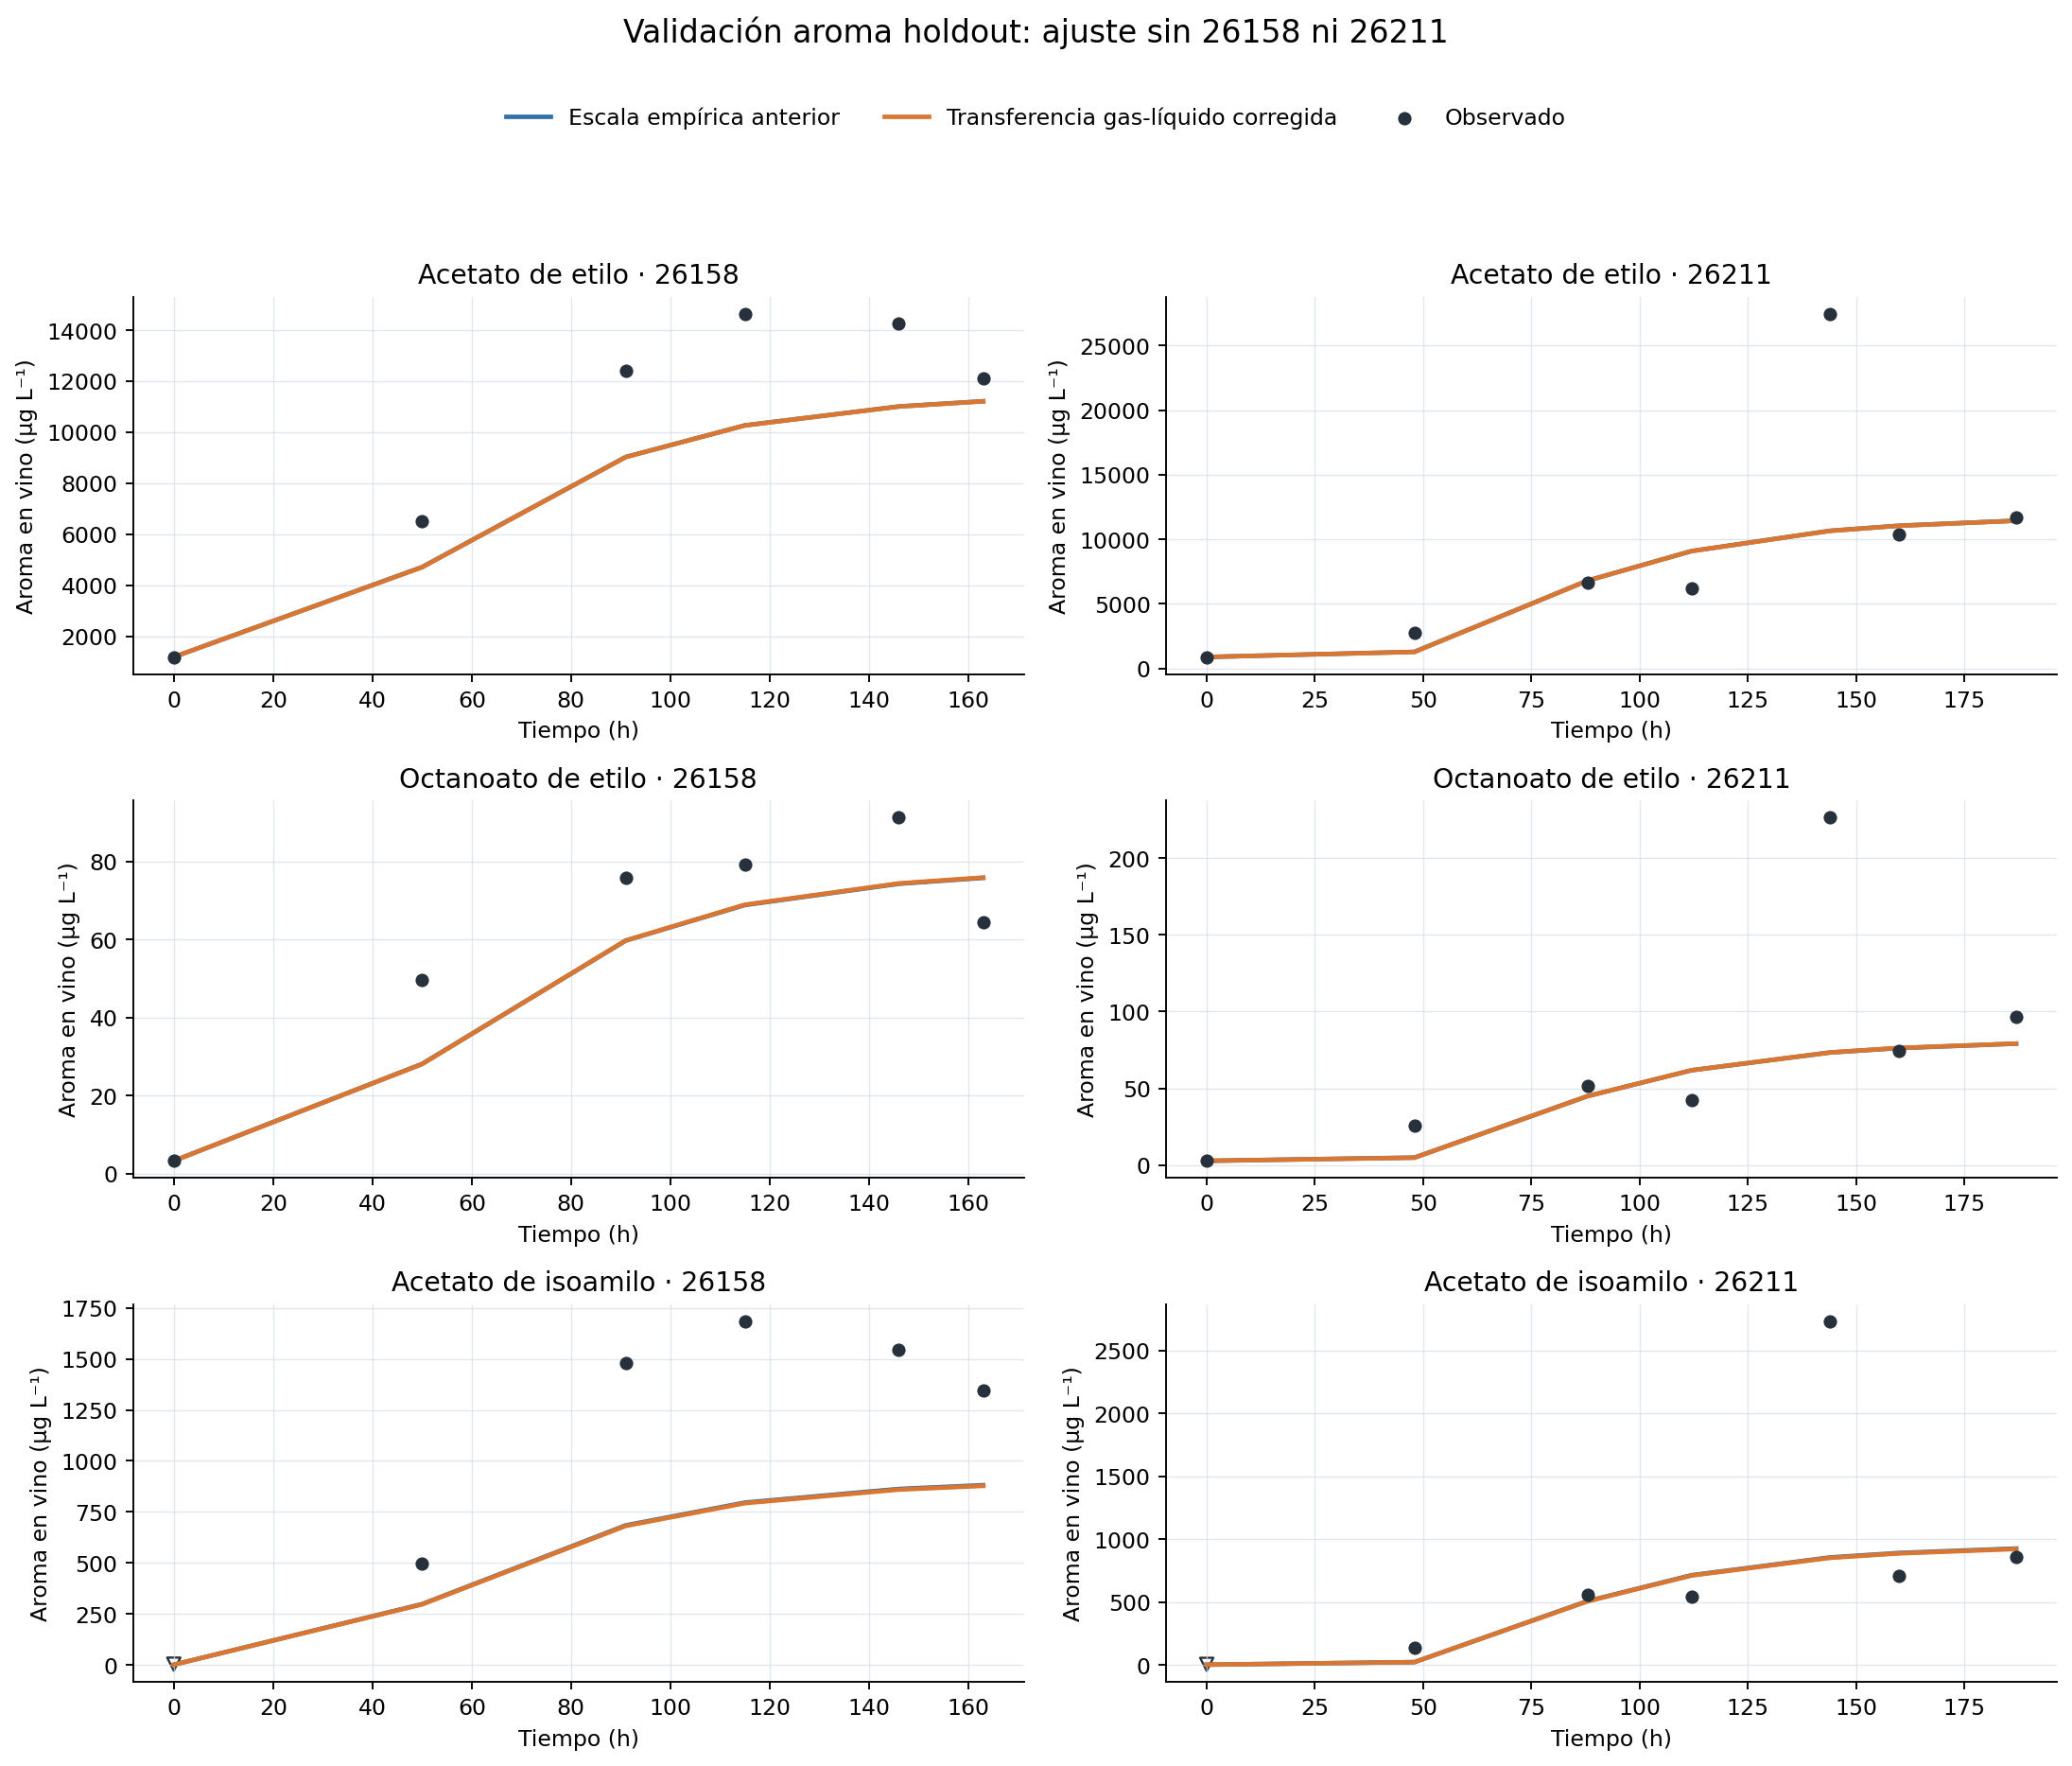

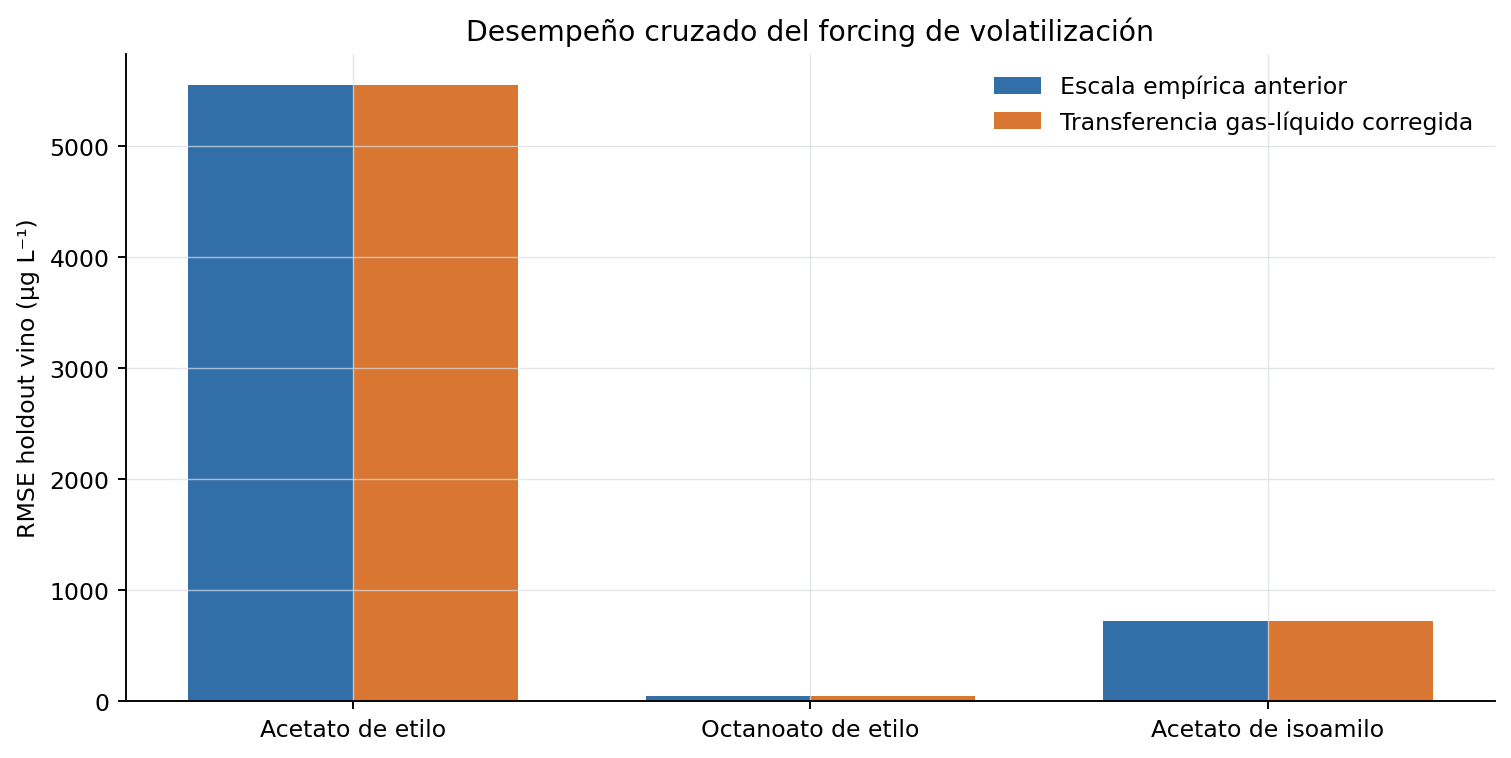

In [4]:
display(result["parameters"].query("fit_scope == 'all_data'").round(5))
display(result["metrics"].query("fit_scope == 'calibration_only' and role == 'holdout'").round(4))
display(Image(filename=analysis.FIGURE_DIR / "holdout_wine_predictions.png"))
display(Image(filename=analysis.FIGURE_DIR / "holdout_wine_rmse_comparison.png"))

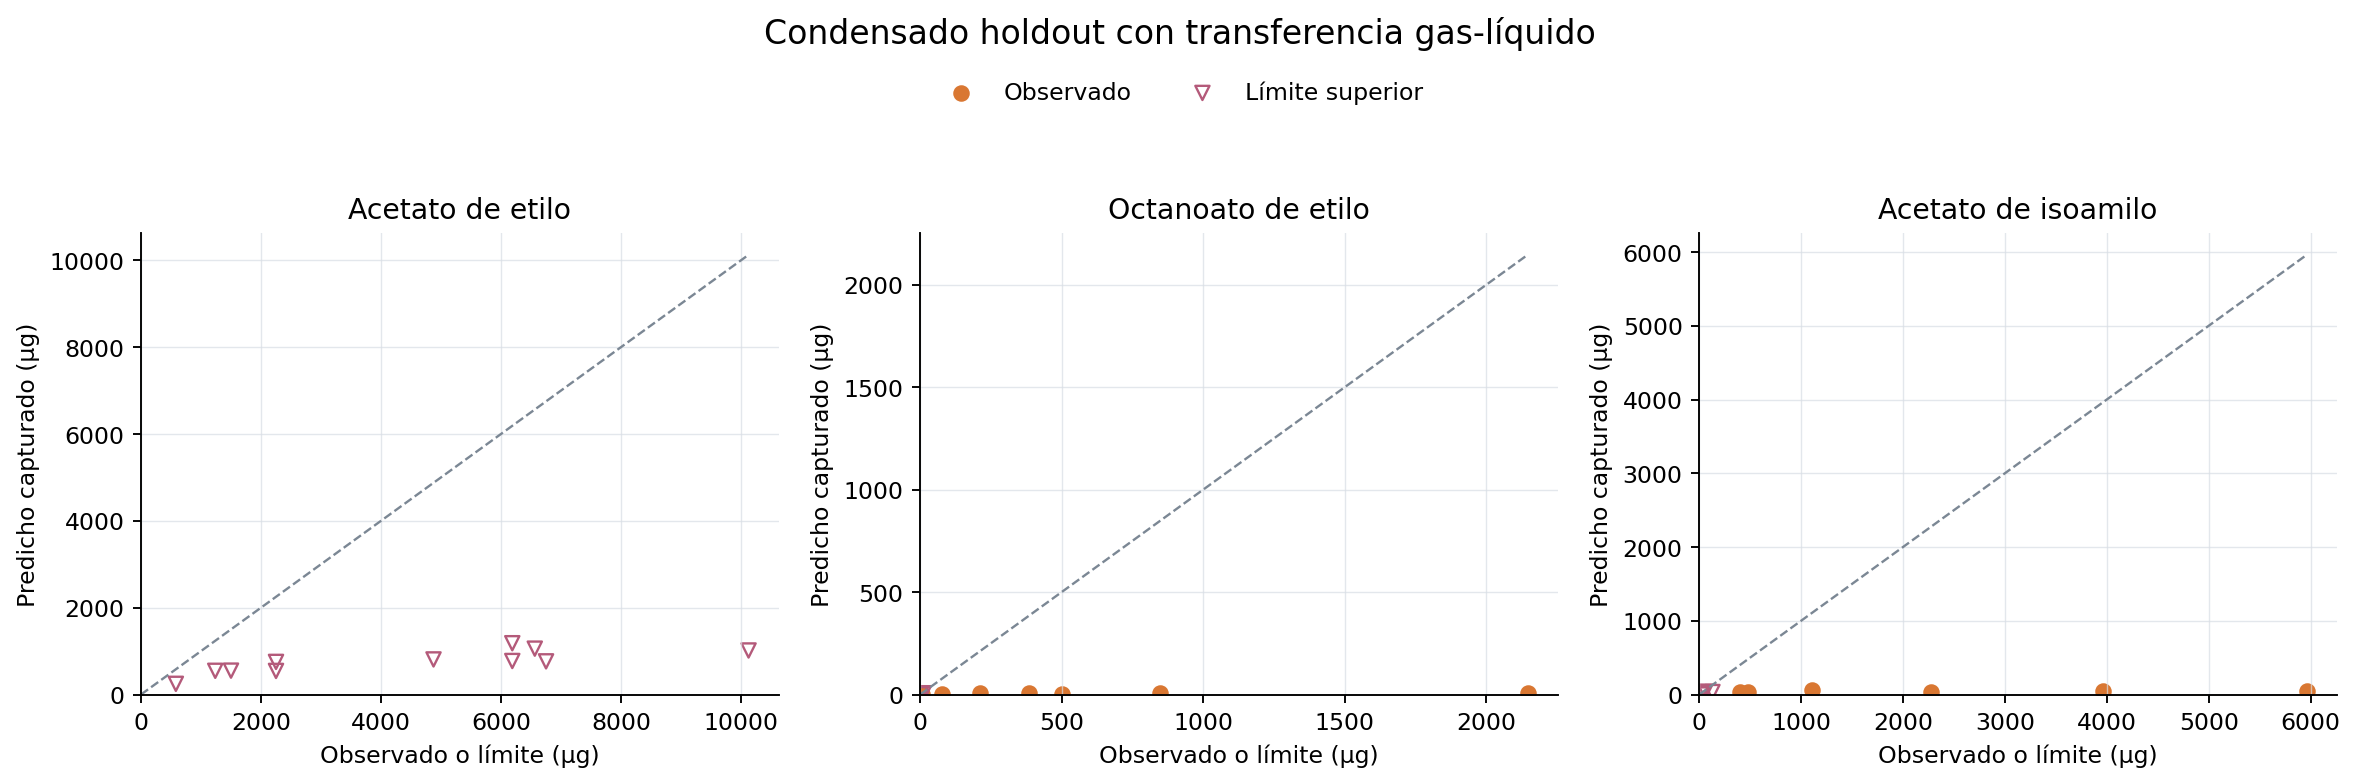

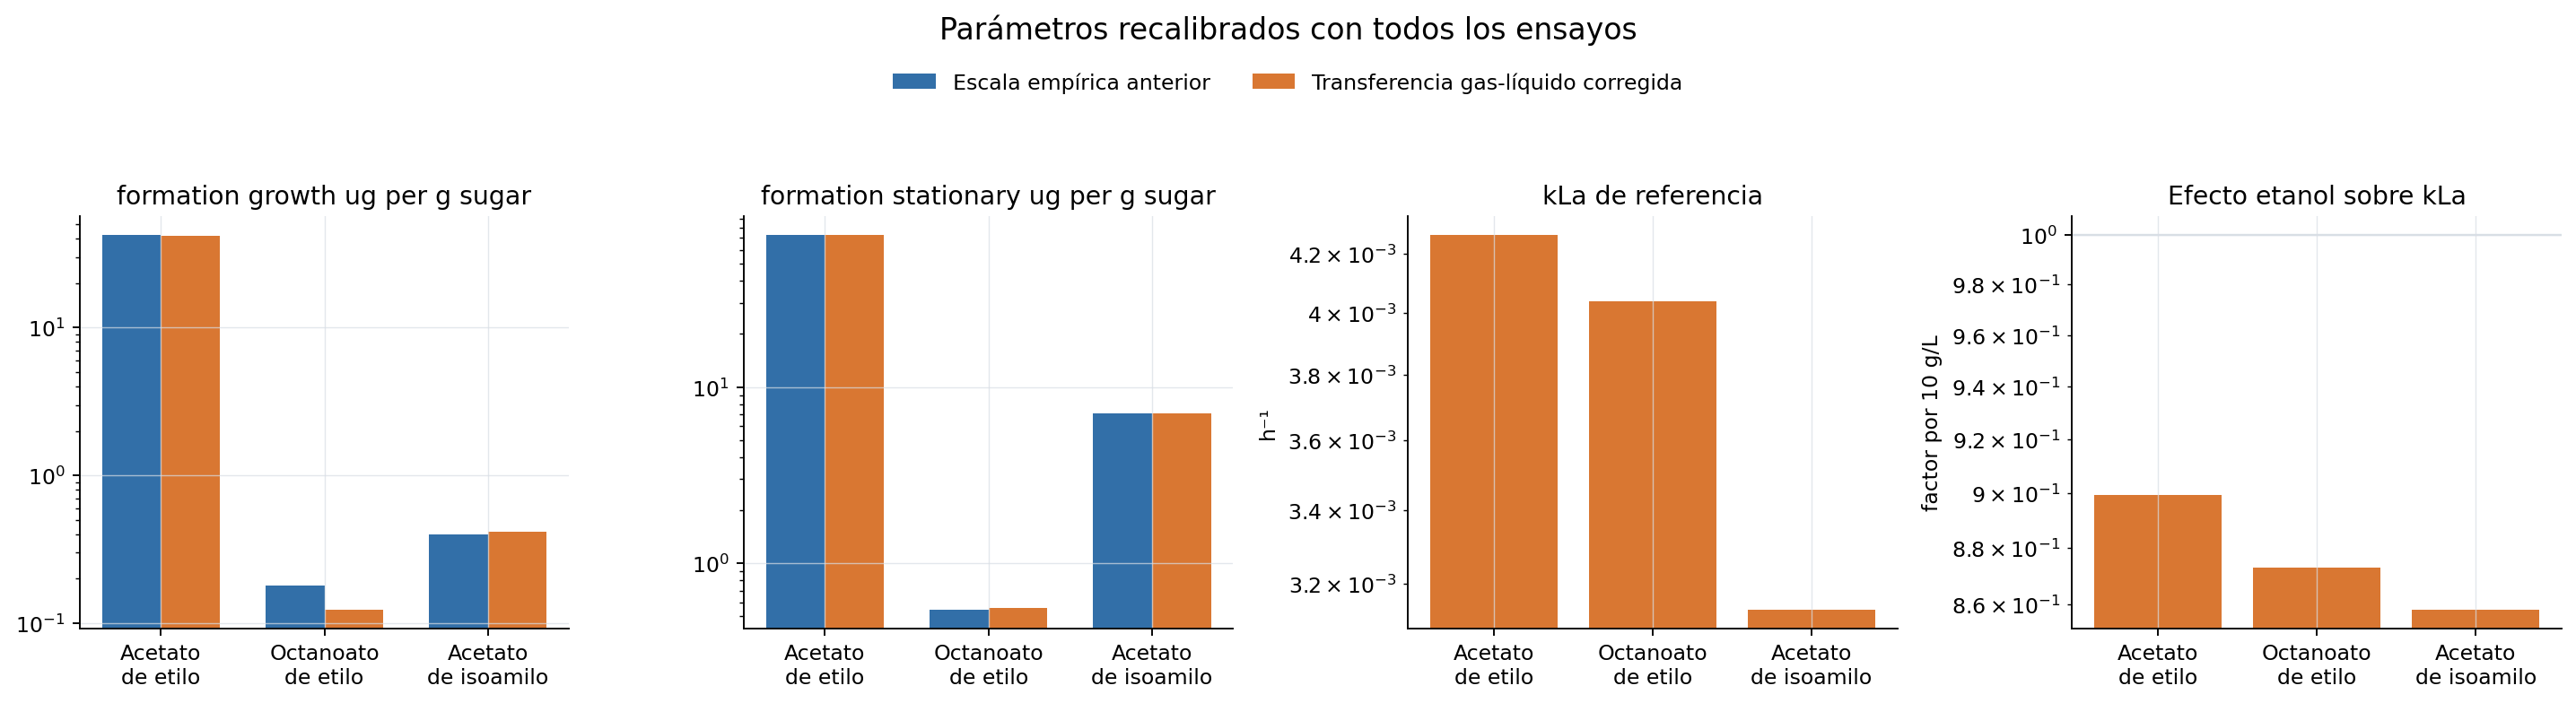

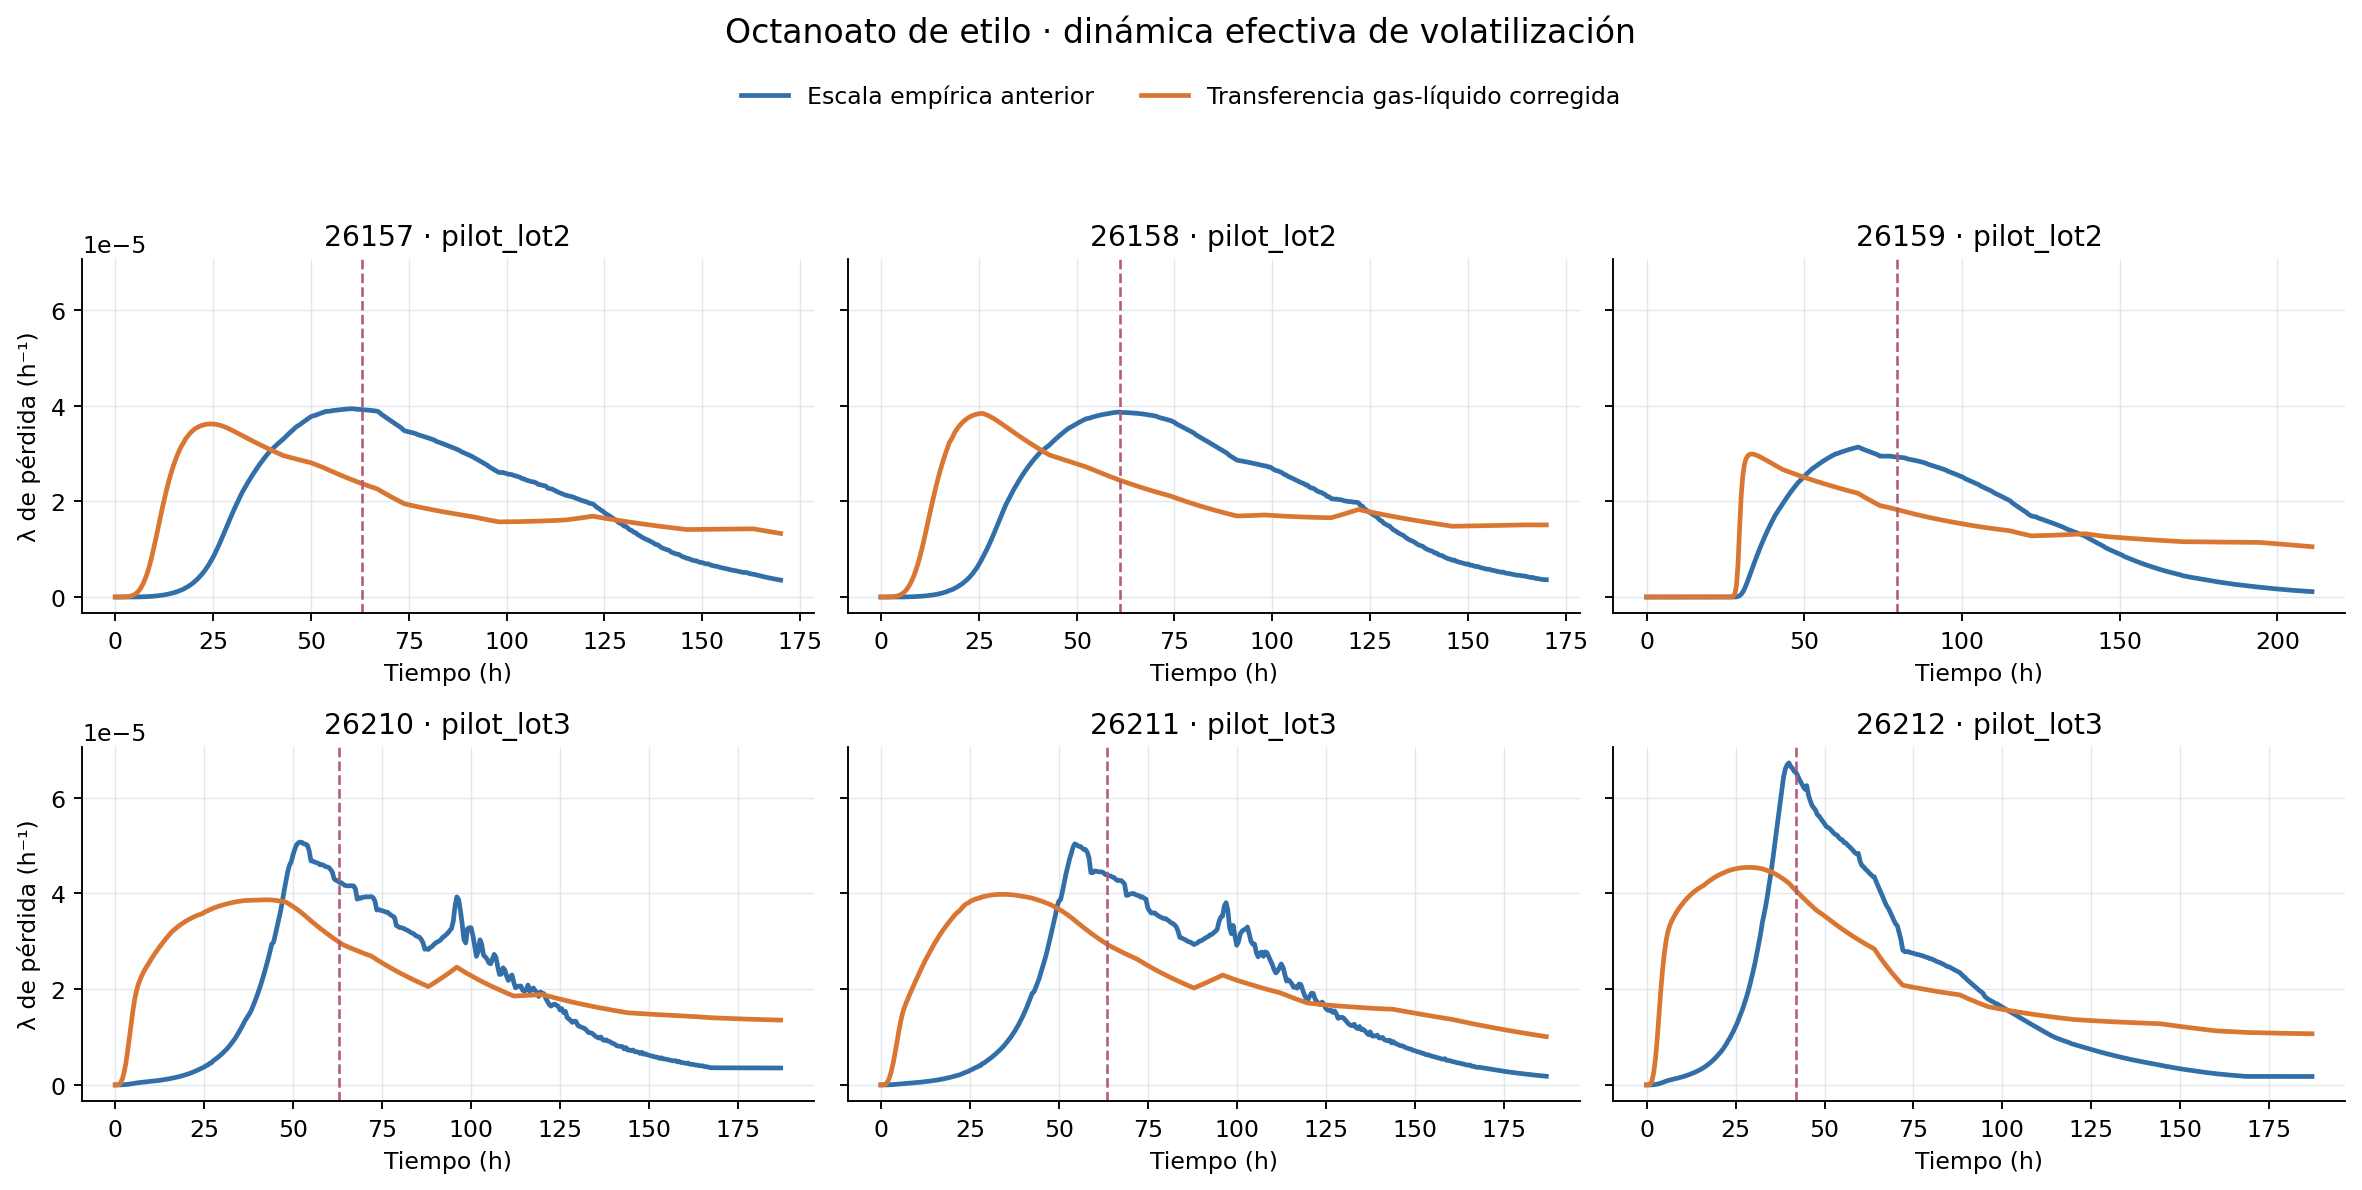

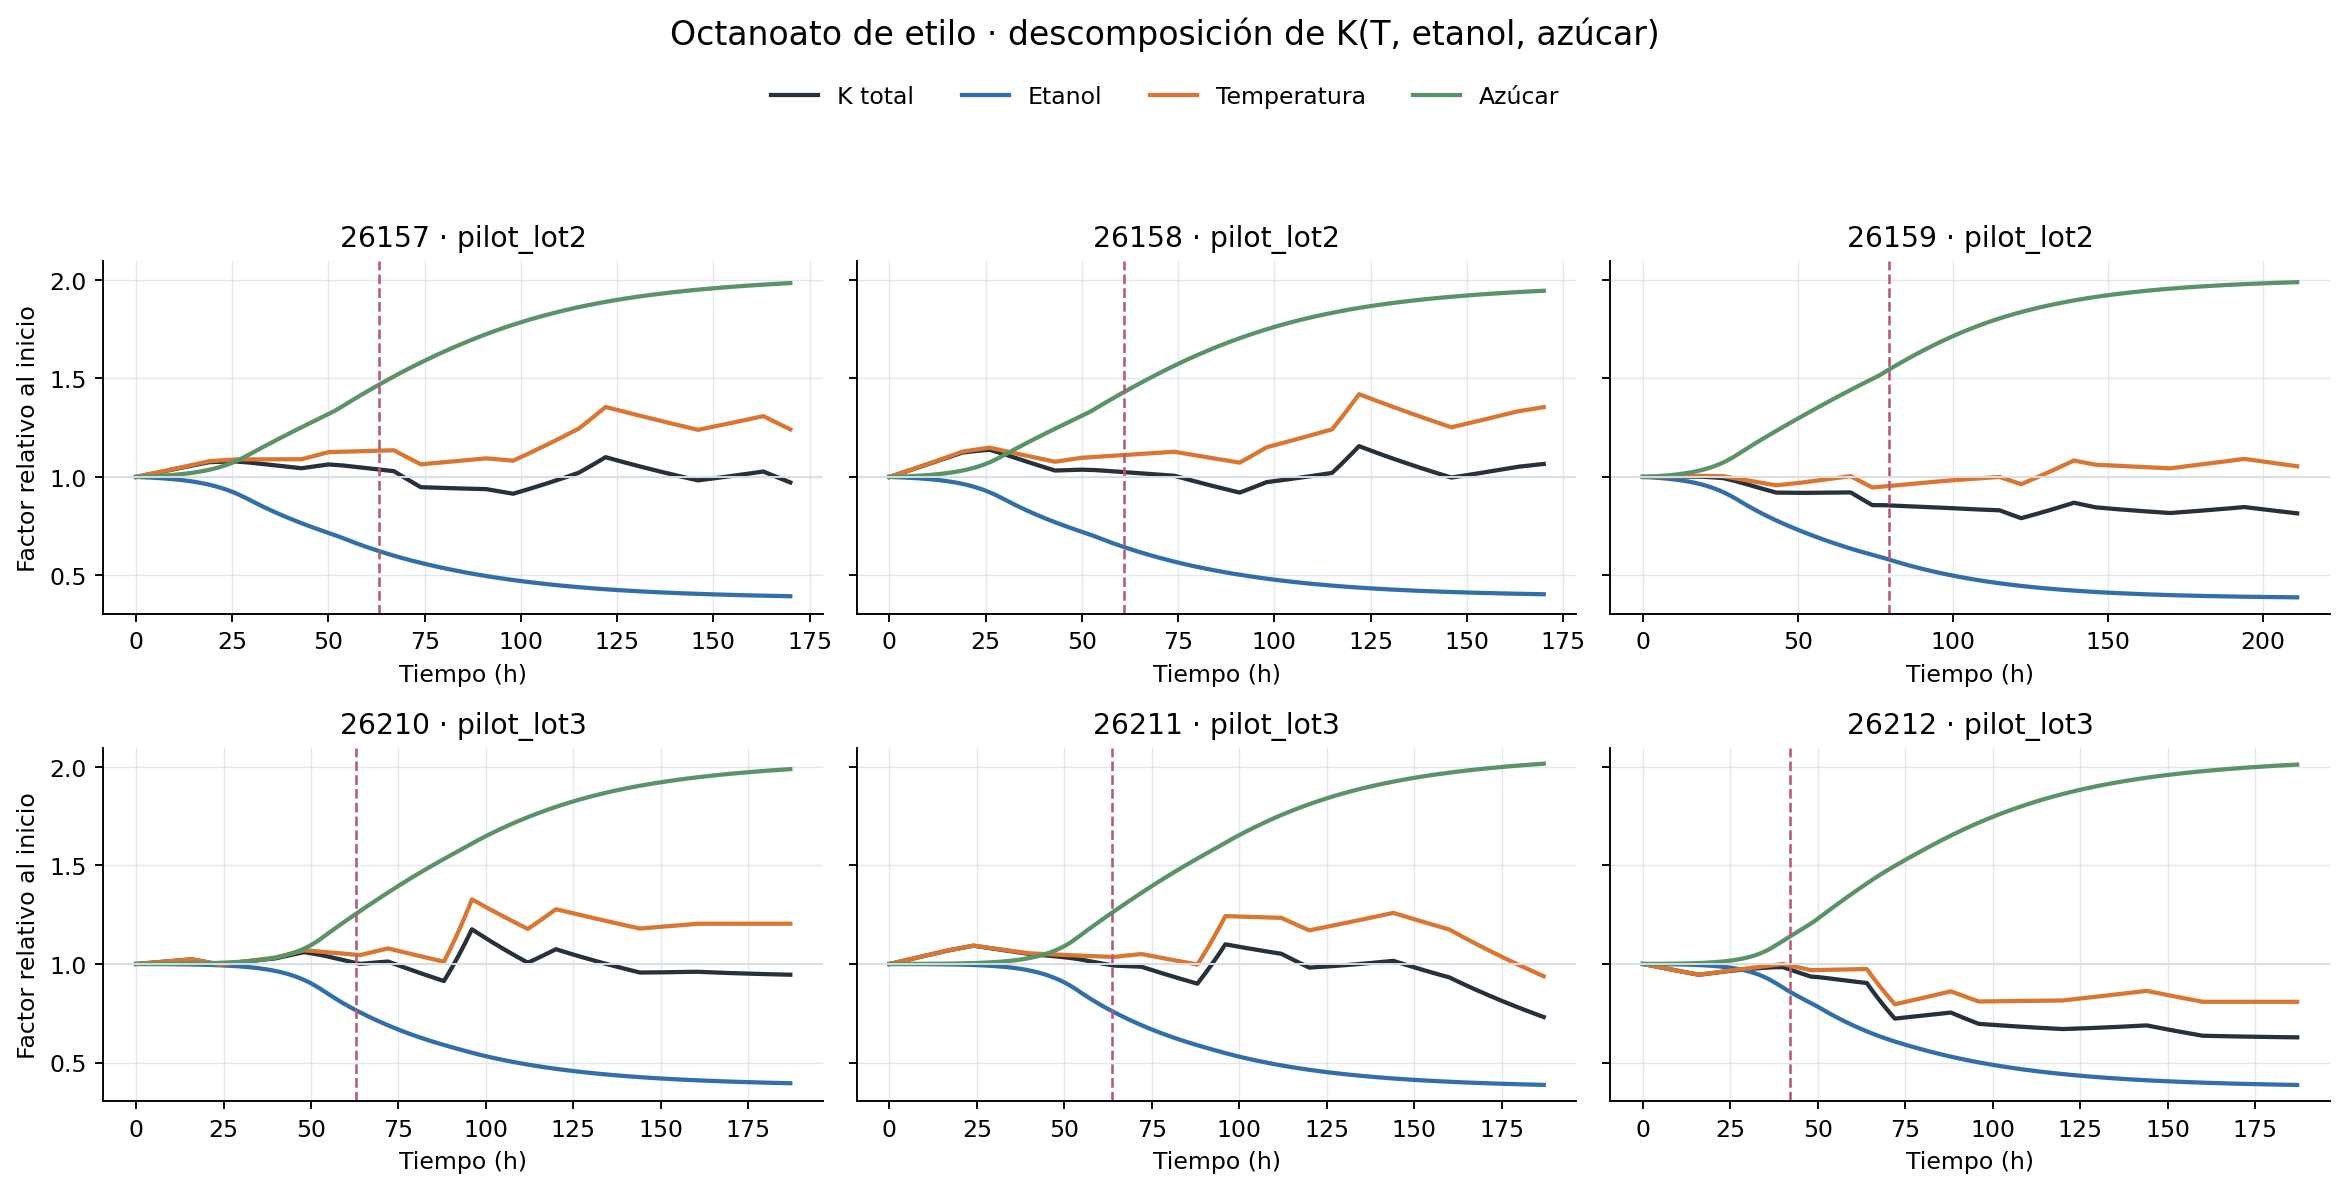

In [5]:
display(Image(filename=analysis.FIGURE_DIR / "holdout_condensate_predictions.png"))
display(Image(filename=analysis.FIGURE_DIR / "aroma_parameter_comparison.png"))
display(Image(filename=analysis.FIGURE_DIR / "ethyl_octanoate_loss_dynamics.png"))
display(Image(filename=analysis.FIGURE_DIR / "ethyl_octanoate_partition_decomposition.png"))

## Identificabilidad

,forcing_source,fit_scope,species,objective,objective_per_observation,active_bound_fraction,loss_separately_identified,weak_parameters
9,dynamic_transfer_model,all_data,ethyl_acetate,75.3027,1.0459,0.0,True,formation_growth_ug_per_g_sugar;mass_transfer_...
10,dynamic_transfer_model,all_data,ethyl_octanoate,375.6209,5.2170,0.0,True,formation_growth_ug_per_g_sugar
11,dynamic_transfer_model,all_data,isoamyl_acetate,370.5718,5.1468,0.0,True,formation_growth_ug_per_g_sugar


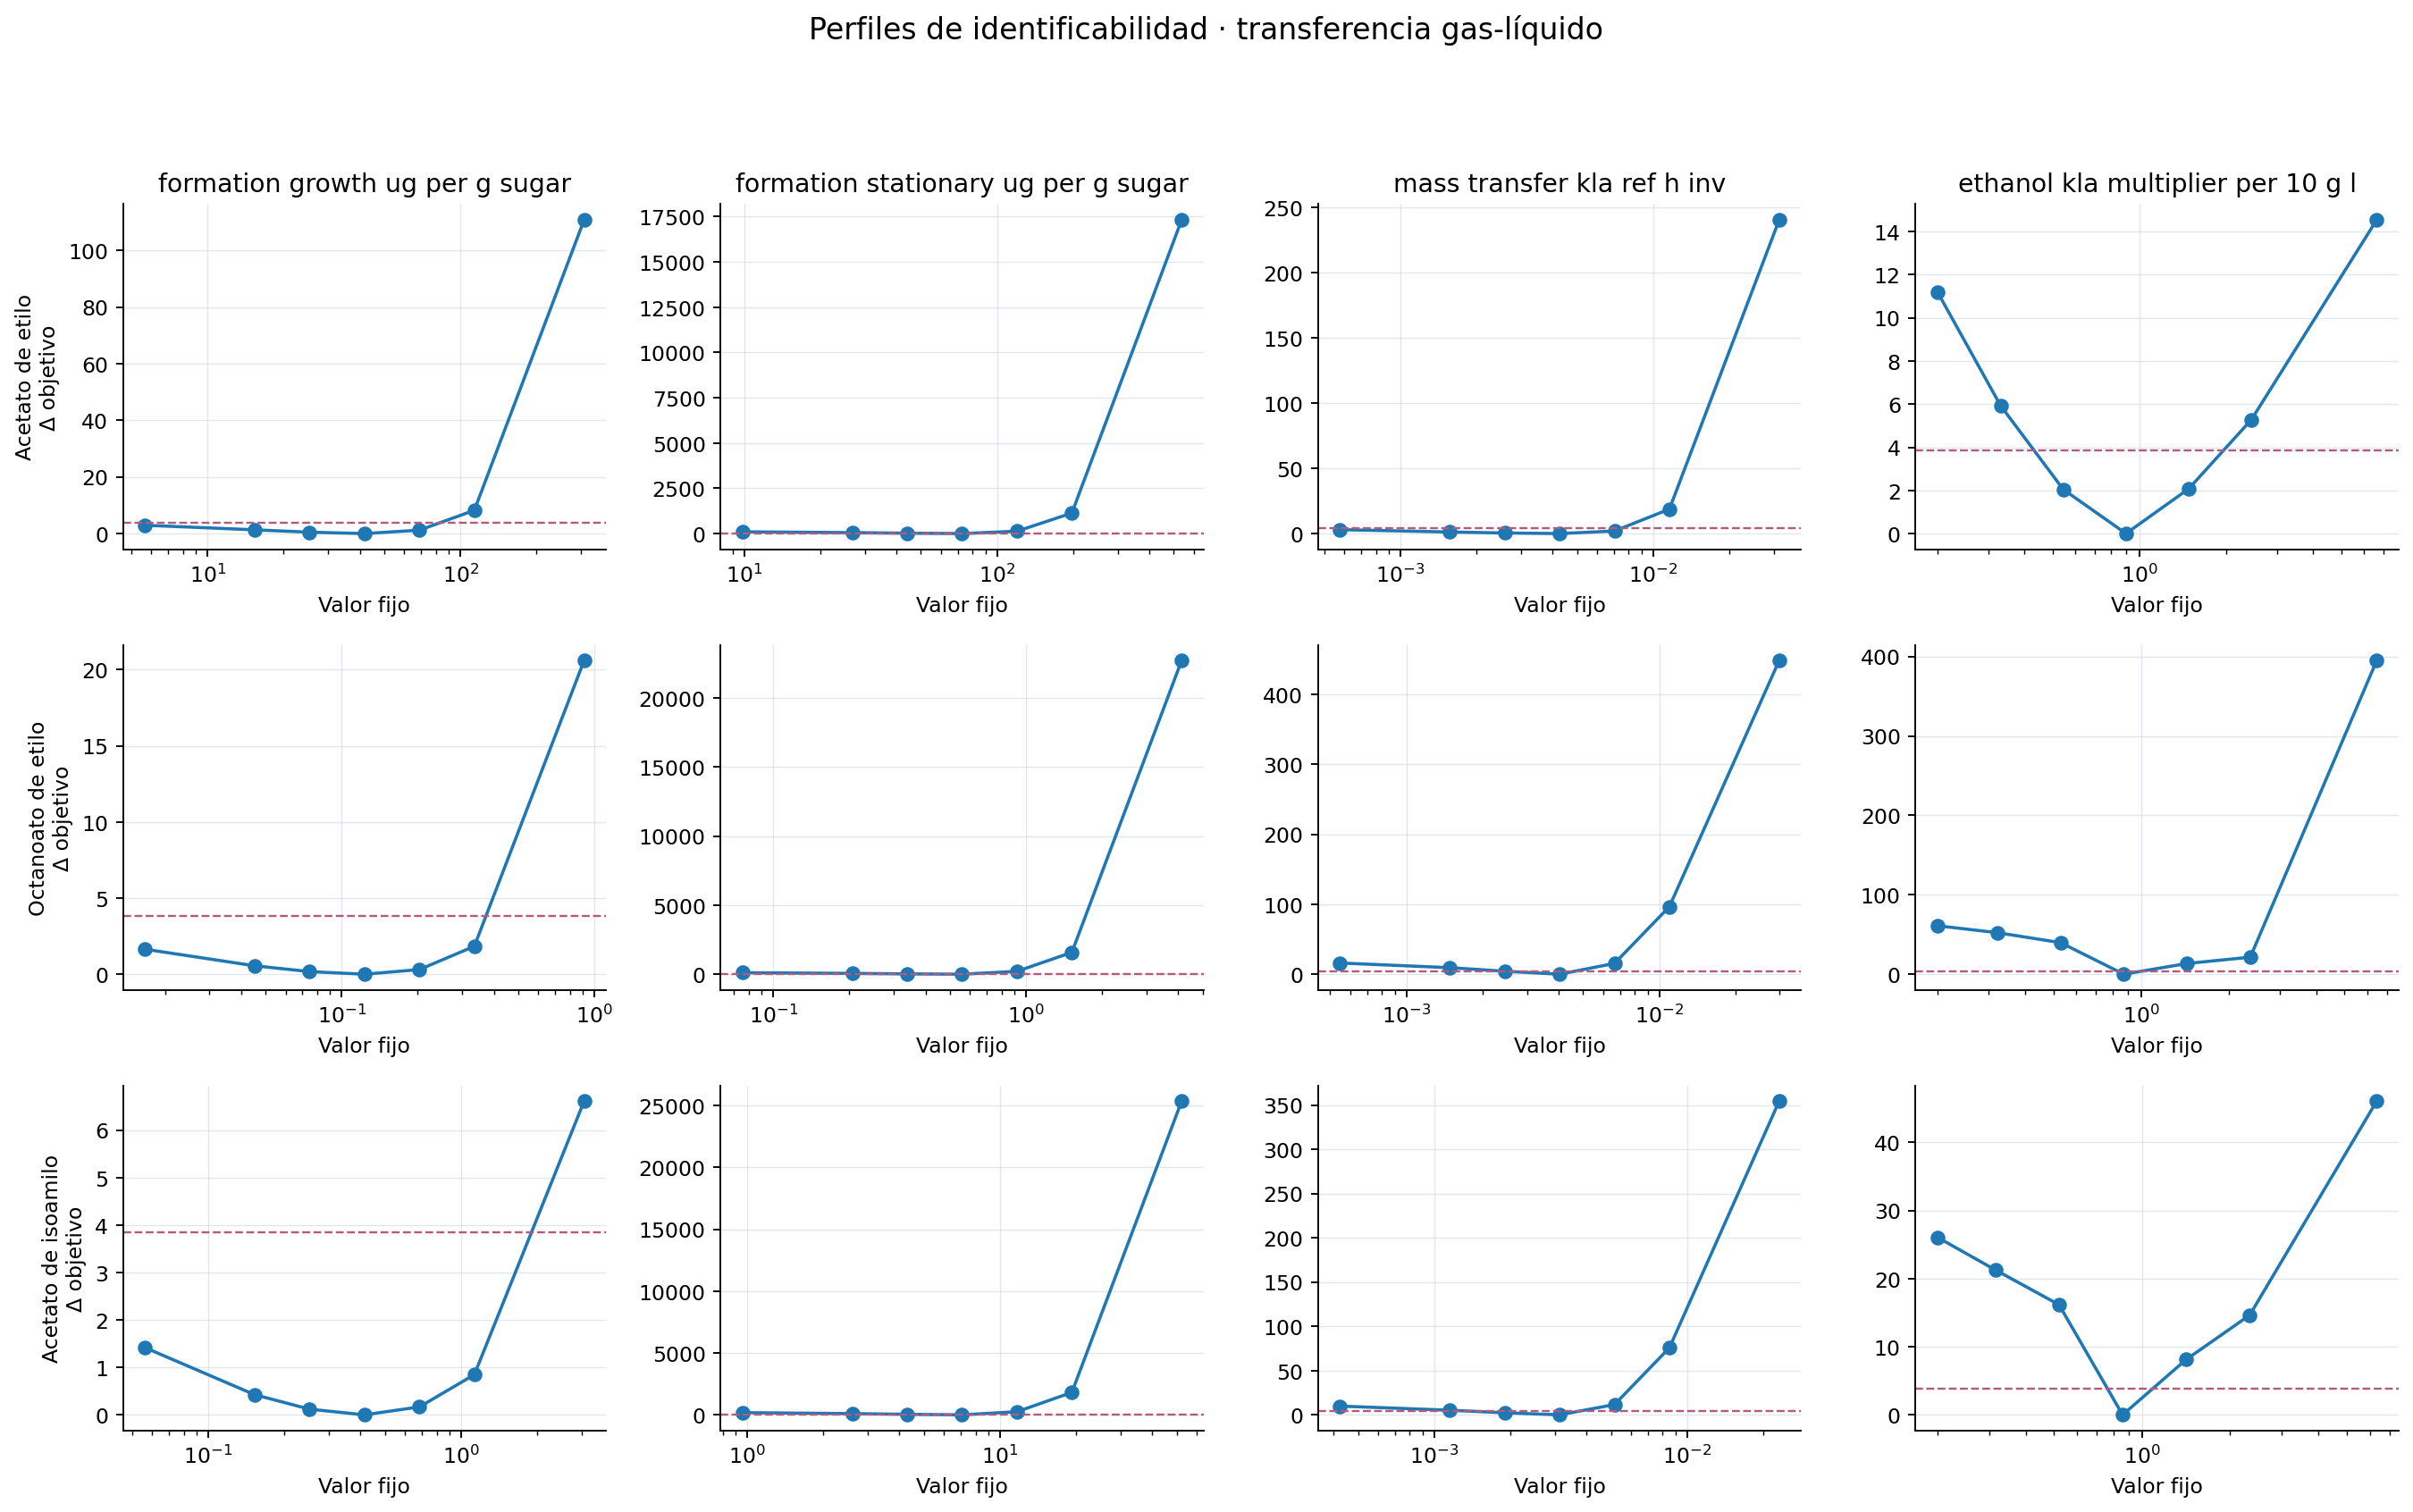

In [6]:
display(result["validation"].query("forcing_source == 'dynamic_transfer_model' and fit_scope == 'all_data'").round(4))
display(Image(filename=analysis.FIGURE_DIR / "release_forcing_profile_likelihood.png"))

## Takeaways

La comparación relevante es el desempeño holdout con el mismo rCO₂, cambiando solamente el operador de volatilización. Una mejora no implica por sí sola identificabilidad completa: `kLa` puede saturarse cuando la corriente gaseosa ya sale cerca del equilibrio. Los límites de detección se incorporan como censura, no como ceros.

In [7]:
print("Notebook ejecutado sin errores.")
print("Figuras embebidas:", len(result["figures"]))
print("Artefactos:", analysis.RESULTS_DIR.relative_to(ROOT))

Notebook ejecutado sin errores.
Figuras embebidas: 9
Artefactos: fermentation_model\pilot_2026\results\aroma_dynamic_transfer_recalibration_2026
